In [3]:
!pip install tensorflow-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.8/251.8 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 63.0 MB/s eta 0:00:00
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-0.4.1
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.18.0
    Uninstalling tensorboard-2.18.0:
      Successfully uninstalled tensorboard-2.18.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.18.0 requires ml-dtypes<0.5.0,>=0.4.0, but you have ml-dtypes 0.5.1 which is incompatible.
tensorflow 2.18.0 requires tensorboard<2.19,>=2.18, but you have tensorboard 2.19.0 which is incompatible.


In [4]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
dataset = pd.read_csv('Churn_Modelling.csv')

In [7]:
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
X = dataset.iloc[:, 3:13]
y = dataset.iloc[:, 13]

In [9]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [10]:
y

,Exited
0,1
1,0
2,1
3,0
4,0
...,...
9995,0
9996,0
9997,1
9998,1


In [13]:
# Feature Engineering

geography = pd.get_dummies(X['Geography'], drop_first=True)
gender = pd.get_dummies(X['Gender'], drop_first=True)

In [16]:
X = X.drop(['Geography', 'Gender'], axis=1)

In [17]:
x.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,42,2,0.00,1,1,1,101348.88
1,608,41,1,83807.86,1,0,1,112542.58
2,502,42,8,159660.80,3,1,0,113931.57
3,699,39,1,0.00,2,0,0,93826.63
4,850,43,2,125510.82,1,1,1,79084.10


Concatination

In [21]:
X = pd.concat([X, geography, gender], axis=1)

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [23]:
## Feature Scaling

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [24]:
X_train

array([[ 0.16958176, -0.46460796,  0.00666099, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-2.30455945,  0.30102557, -1.37744033, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-1.19119591, -0.94312892, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       ...,
       [ 0.9015152 , -0.36890377,  0.00666099, ..., -0.5698444 ,
        -0.57369368,  0.91601335],
       [-0.62420521, -0.08179119,  1.39076231, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-0.28401079,  0.87525072, -1.37744033, ...,  1.75486502,
        -0.57369368, -1.09168714]])

In [25]:
X_test

array([[-0.55204276, -0.36890377,  1.04473698, ...,  1.75486502,
        -0.57369368, -1.09168714],
       [-1.31490297,  0.10961719, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       [ 0.57162971,  0.30102557,  1.04473698, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       ...,
       [-0.74791227, -0.27319958, -1.37744033, ..., -0.5698444 ,
         1.74309049,  0.91601335],
       [-0.00566991, -0.46460796, -0.33936434, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-0.79945688, -0.84742473,  1.04473698, ...,  1.75486502,
        -0.57369368,  0.91601335]])

In [26]:
X_train.shape

(8000, 11)

In [27]:
### Lets create ANN
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU, PReLU, ELU, ReLU
from tensorflow.keras.layers import Dropout

In [28]:
## Let's initialize the ANN
classifier = Sequential()

In [29]:
## adding the input layer
classifier.add(Dense(units=11, activation='relu'))

In [30]:
## adding the first hidden layer
classifier.add(Dense(units=7, activation='relu'))

## adding dropout layer
# classifier.add(Dropout(0.3))

In [31]:
## adding the 2nd hidden layer
classifier.add(Dense(units=6, activation='relu'))
## adding dropout layer
# classifier.add(Dropout(0.3))


In [33]:
### adding the output layer
classifier.add(Dense(units=1, activation='sigmoid'))

In [32]:
classifier.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [34]:
import tensorflow as tf
opt = tf.keras.optimizers.Adam(learning_rate=0.01)

In [35]:
model_history = classifier.fit(X_train, y_train, validation_split=0.33, batch_size=10, epochs=100)

Epoch 1/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7212 - loss: 0.5820 - val_accuracy: 0.8073 - val_loss: 0.4548
Epoch 2/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8097 - loss: 0.4459 - val_accuracy: 0.8217 - val_loss: 0.4148
Epoch 3/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8457 - loss: 0.3722 - val_accuracy: 0.8266 - val_loss: 0.3874
Epoch 4/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8406 - loss: 0.3649 - val_accuracy: 0.8372 - val_loss: 0.3770
Epoch 5/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8438 - loss: 0.3569 - val_accuracy: 0.8379 - val_loss: 0.3747
Epoch 6/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8517 - loss: 0.3499 - val_accuracy: 0.8410 - val_loss: 0.3720
Epoch 7/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8708 - loss: 0.3150 - val_accuracy: 0.8455 - val_loss: 0.3677
Epoch 8/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8613 - loss: 0.3427 - val_accu

In [37]:
model_history.history

{'accuracy': [0.7801828980445862,
  0.8227280974388123,
  0.8445605635643005,
  0.8509050011634827,
  0.8529576659202576,
  0.8550102710723877,
  0.8540772795677185,
  0.8583691120147705,
  0.8609815239906311,
  0.8606083393096924,
  0.8593021035194397,
  0.8593021035194397,
  0.8613547086715698,
  0.8613547086715698,
  0.8645269870758057,
  0.8609815239906311,
  0.8617279529571533,
  0.8628475666046143,
  0.8637805581092834,
  0.8619145154953003,
  0.8615413308143616,
  0.8613547086715698,
  0.8630341291427612,
  0.8624743223190308,
  0.8637805581092834,
  0.8630341291427612,
  0.8613547086715698,
  0.863220751285553,
  0.8630341291427612,
  0.8617279529571533,
  0.8626609444618225,
  0.8624743223190308,
  0.8628475666046143,
  0.8639671802520752,
  0.8639671802520752,
  0.8658331632614136,
  0.8635939359664917,
  0.8654599785804749,
  0.8650867938995361,
  0.8652733564376831,
  0.8660197854042053,
  0.8656466007232666,
  0.8662064075469971,
  0.8686321973800659,
  0.8660197854042053,

In [39]:
model_history.history.keys

<function dict.keys>

In [41]:
### Early stopping
import tensorflow as tf
from tensorflow import keras
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0,
)

In [42]:
model_history = classifier.fit(X_train, y_train, validation_split=0.33, batch_size=10, epochs=100, callbacks=[early_stopping])

Epoch 1/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8797 - loss: 0.2862 - val_accuracy: 0.8573 - val_loss: 0.3618
Epoch 2/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8690 - loss: 0.3017 - val_accuracy: 0.8561 - val_loss: 0.3590
Epoch 3/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8701 - loss: 0.2999 - val_accuracy: 0.8550 - val_loss: 0.3604
Epoch 4/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8719 - loss: 0.3049 - val_accuracy: 0.8535 - val_loss: 0.3578
Epoch 5/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8738 - loss: 0.3020 - val_accuracy: 0.8591 - val_loss: 0.3635
Epoch 6/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8682 - loss: 0.3076 - val_accuracy: 0.8584 - val_loss: 0.3612
Epoch 7/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8721 - loss: 0.3008 - val_accuracy: 0.8561 - val_loss: 0.3601
Epoch 8/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8718 - loss: 0.3020 - val_accu

In [44]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

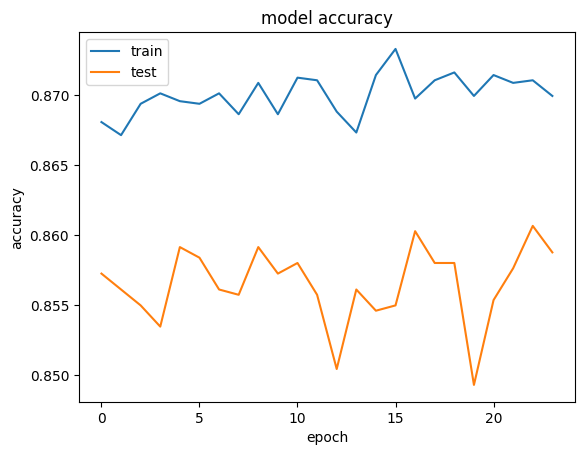

In [46]:
## summarize history for accuracy
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

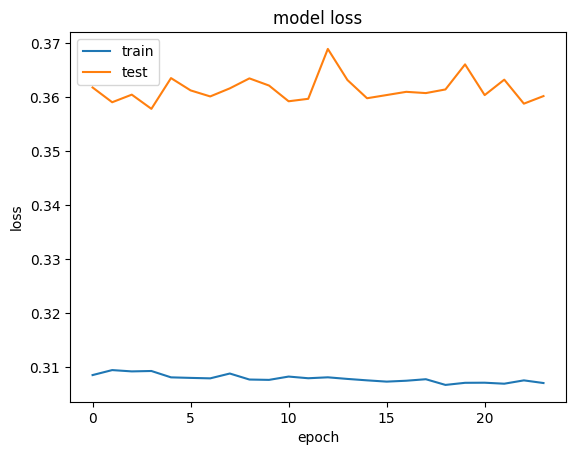

In [47]:
## summarize history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [48]:
## making the predictions and evaluating the model

## predicting the test set results

y_pred = classifier.predict(X_test)
y_pred = (y_pred > 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


In [49]:
## make the confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

In [50]:
## calculate the accuracy
from sklearn.metrics import accuracy_score
score = accuracy_score(y_pred, y_test)

In [51]:
score

0.8535

In [52]:
## get the weights
classifier.get_weights()

[array([[ 0.1674247 , -0.1909472 ,  0.26984188, -0.17473648, -0.01252944,
         -0.03765077, -0.01861227, -0.10279891,  0.35417795, -0.15772669,
          0.24702112],
        [ 0.2450834 , -0.2942088 , -0.6282988 ,  0.23771654,  0.0315293 ,
          0.28134507, -0.8686536 ,  1.0298961 ,  0.6638319 ,  1.5211929 ,
          0.52238864],
        [ 0.49845955, -0.41469336, -0.34393197,  0.16735004, -0.01263194,
          0.3492089 ,  0.30067664, -0.32572109, -0.2331865 , -0.14956357,
         -0.05419085],
        [-0.6433961 ,  0.1823547 , -0.796512  ,  0.6646025 , -0.89235234,
          0.16941439,  0.03323475,  0.27665675,  0.31719485,  0.10043166,
         -0.21491209],
        [-0.40174332,  0.5017789 ,  0.25756943, -0.7101628 , -1.0463192 ,
          1.122969  ,  0.4895622 , -0.02090372, -0.22346568,  0.28072202,
          0.758197  ],
        [-0.23992404, -0.2573181 ,  0.09789812, -0.18117882, -0.01027949,
         -0.16299213,  0.00362733,  0.36440936,  0.24928355, -0.2859471